<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkPY0220ENSkillsNetwork900-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1>Extracting and Visualizing Stock Data</h1>
<h2>Description</h2>


Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data. In this assignment, you will extract some stock data, you will then display this data in a graph.


<h2>Table of Contents</h2>
<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li>Define a Function that Makes a Graph</li>
        <li>Question 1: Use yfinance to Extract Stock Data</li>
        <li>Question 2: Use Webscraping to Extract Tesla Revenue Data</li>
        <li>Question 3: Use yfinance to Extract Stock Data</li>
        <li>Question 4: Use Webscraping to Extract GME Revenue Data</li>
        <li>Question 5: Plot Tesla Stock Graph</li>
        <li>Question 6: Plot GameStop Stock Graph</li>
    </ul>
<p>
    Estimated Time Needed: <strong>30 min</strong></p>
</div>

<hr>


In [1]:
!pip install yfinance==0.1.67
!mamba install bs4==4.10.0 -y
!pip install nbformat==4.2.0


                  __    __    __    __
                 /  \  /  \  /  \  /  \
                /    \/    \/    \/    \
███████████████/  /██/  /██/  /██/  /████████████████████████
              /  / \   / \   / \   / \  \____
             /  /   \_/   \_/   \_/   \    o \__,
            / _/                       \_____/  `
            |/
        ███╗   ███╗ █████╗ ███╗   ███╗██████╗  █████╗
        ████╗ ████║██╔══██╗████╗ ████║██╔══██╗██╔══██╗
        ██╔████╔██║███████║██╔████╔██║██████╔╝███████║
        ██║╚██╔╝██║██╔══██║██║╚██╔╝██║██╔══██╗██╔══██║
        ██║ ╚═╝ ██║██║  ██║██║ ╚═╝ ██║██████╔╝██║  ██║
        ╚═╝     ╚═╝╚═╝  ╚═╝╚═╝     ╚═╝╚═════╝ ╚═╝  ╚═╝

        mamba (1.4.2) supported by @QuantStack

        GitHub:  https://github.com/mamba-org/mamba
        Twitter: https://twitter.com/QuantStack

█████████████████████████████████████████████████████████████


Looking for: ['bs4==4.10.0']

[+] 0.0s
pkgs/main/linux-64 ━━━━━━━━━╸━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Define Graphing Function


In this section, we define the function `make_graph`. You don't have to know how the function works, you should only care about the inputs. It takes a dataframe with stock data (dataframe must contain Date and Close columns), a dataframe with revenue data (dataframe must contain Date and Revenue columns), and the name of the stock.


In [ ]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Historical Share Price", "Historical Revenue"), vertical_spacing = .3)
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data_specific.Date, infer_datetime_format=True), y=stock_data_specific.Close.astype("float"), name="Share Price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data_specific.Date, infer_datetime_format=True), y=revenue_data_specific.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False,
    height=900,
    title=stock,
    xaxis_rangeslider_visible=True)
    fig.show()

## Question 1: Use yfinance to Extract Stock Data


Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is `TSLA`.


In [4]:
tsla = yf.Ticker("TSLA")

Using the ticker object and the function `history` extract stock information and save it in a dataframe named `tesla_data`. Set the `period` parameter to `max` so we get information for the maximum amount of time.


In [ ]:
try:
    tesla_data = tsla.history(period="max")
    if tesla_data.empty:
        print("Warning: No Tesla stock data retrieved")
    else:
        print(f"Successfully retrieved {len(tesla_data)} rows of Tesla stock data")
except Exception as e:
    print(f"Error retrieving Tesla stock data: {e}")
    tesla_data = pd.DataFrame()

**Reset the index** using the `reset_index(inplace=True)` function on the tesla_data DataFrame and display the first five rows of the `tesla_data` dataframe using the `head` function. Take a screenshot of the results and code from the beginning of Question 1 to the results below.


In [ ]:
if not tesla_data.empty:
    tesla_data.reset_index(inplace=True)
    # Validate required columns exist
    required_columns = ['Date', 'Close']
    if all(col in tesla_data.columns for col in required_columns):
        print("Tesla stock data validated successfully")
    else:
        print(f"Warning: Missing required columns. Available columns: {tesla_data.columns.tolist()}")
else:
    print("Cannot reset index - Tesla data is empty")

In [7]:
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29,1.266667,1.666667,1.169333,1.592667,281494500,0,0.0
1,2010-06-30,1.719333,2.028000,1.553333,1.588667,257806500,0,0.0
2,2010-07-01,1.666667,1.728000,1.351333,1.464000,123282000,0,0.0
3,2010-07-02,1.533333,1.540000,1.247333,1.280000,77097000,0,0.0
4,2010-07-06,1.333333,1.333333,1.055333,1.074000,103003500,0,0.0


## Question 2: Use Webscraping to Extract Tesla Revenue Data


Use the `requests` library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm Save the text of the response as a variable named `html_data`.


In [ ]:
try:
    response = requests.get("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm")
    response.raise_for_status()  # Raise an error for bad status codes
    html_data = response.text
    print("Tesla revenue data downloaded successfully")
except requests.exceptions.RequestException as e:
    print(f"Error downloading Tesla revenue data: {e}")
    html_data = None

Parse the html data using `beautiful_soup`.


In [ ]:
if html_data:
    try:
        soup = BeautifulSoup(html_data, 'html.parser')
        print("HTML parsed successfully")
    except Exception as e:
        print(f"Error parsing HTML: {e}")
        soup = None
else:
    print("No HTML data to parse")
    soup = None

Using `BeautifulSoup` or the `read_html` function extract the table with `Tesla Quarterly Revenue` and store it into a dataframe named `tesla_revenue`. The dataframe should have columns `Date` and `Revenue`.


<details><summary>Click here if you need help locating the table</summary>

```
    
Below is the code to isolate the table, you will now need to loop through the rows and columns like in the previous lab
    
soup.find_all("tbody")[1]
    
If you want to use the read_html function the table is located at index 1


```

</details>


In [10]:
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

In [ ]:
revenue_rows = []

if soup:
    try:
        revenue_table = soup.find_all("tbody")[1]
        for row in revenue_table.find_all("tr"):
            col = row.find_all("td")
            if len(col) >= 2:  # Ensure row has at least 2 columns
                date = col[0].text
                revenue = col[1].text
                
                # Collect data of each row
                revenue_rows.append({"Date": date, "Revenue": revenue})
        
        # Create dataframe from collected rows
        tesla_revenue = pd.DataFrame(revenue_rows, columns=["Date", "Revenue"])
        print(f"Successfully extracted {len(tesla_revenue)} rows of Tesla revenue data")
    except Exception as e:
        print(f"Error extracting Tesla revenue data: {e}")
        tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])
else:
    print("Cannot extract revenue data - no parsed HTML available")
    tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

Execute the following line to remove the comma and dollar sign from the `Revenue` column. 


In [14]:
tesla_revenue["Revenue"].head()

0    $21,454
1    $16,934
2    $18,756
3    $17,719
4    $13,757
Name: Revenue, dtype: object

In [ ]:
if not tesla_revenue.empty and 'Revenue' in tesla_revenue.columns:
    tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$', "", regex=True)
    print("Tesla revenue data cleaned successfully")
else:
    print("Warning: Cannot clean Tesla revenue data - dataframe is empty or missing Revenue column")

Execute the following lines to remove an null or empty strings in the Revenue column.


In [ ]:
if not tesla_revenue.empty:
    tesla_revenue.dropna(inplace=True)
    tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]
    print(f"Tesla revenue data after cleanup: {len(tesla_revenue)} rows")
else:
    print("Warning: Tesla revenue dataframe is empty")

Display the last 5 row of the `tesla_revenue` dataframe using the `tail` function. Take a screenshot of the results.


In [20]:
tesla_revenue.tail(5)

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## Question 3: Use yfinance to Extract Stock Data


Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is `GME`.


In [21]:
gme = yf.Ticker("GME")

Using the ticker object and the function `history` extract stock information and save it in a dataframe named `gme_data`. Set the `period` parameter to `max` so we get information for the maximum amount of time.


In [ ]:
try:
    gme_data = gme.history(period="max")
    if gme_data.empty:
        print("Warning: No GME stock data retrieved")
    else:
        print(f"Successfully retrieved {len(gme_data)} rows of GME stock data")
except Exception as e:
    print(f"Error retrieving GME stock data: {e}")
    gme_data = pd.DataFrame()

**Reset the index** using the `reset_index(inplace=True)` function on the gme_data DataFrame and display the first five rows of the `gme_data` dataframe using the `head` function. Take a screenshot of the results and code from the beginning of Question 3 to the results below.


In [ ]:
if not gme_data.empty:
    gme_data.reset_index(inplace=True)
    # Validate required columns exist
    required_columns = ['Date', 'Close']
    if all(col in gme_data.columns for col in required_columns):
        print("GME stock data validated successfully")
    else:
        print(f"Warning: Missing required columns. Available columns: {gme_data.columns.tolist()}")
else:
    print("Cannot reset index - GME data is empty")

In [42]:
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: Use Webscraping to Extract GME Revenue Data


Use the `requests` library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html. Save the text of the response as a variable named `html_data`.


In [ ]:
try:
    response = requests.get("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html")
    response.raise_for_status()  # Raise an error for bad status codes
    html_data = response.text
    print("GME revenue data downloaded successfully")
except requests.exceptions.RequestException as e:
    print(f"Error downloading GME revenue data: {e}")
    html_data = None

Parse the html data using `beautiful_soup`.


In [ ]:
if html_data:
    try:
        soup = BeautifulSoup(html_data, 'html.parser')
        print("HTML parsed successfully")
    except Exception as e:
        print(f"Error parsing HTML: {e}")
        soup = None
else:
    print("No HTML data to parse")
    soup = None

Using `BeautifulSoup` or the `read_html` function extract the table with `GameStop Quarterly Revenue` and store it into a dataframe named `gme_revenue`. The dataframe should have columns `Date` and `Revenue`. Make sure the comma and dollar sign is removed from the `Revenue` column using a method similar to what you did in Question 2.


<details><summary>Click here if you need help locating the table</summary>

```
    
Below is the code to isolate the table, you will now need to loop through the rows and columns like in the previous lab
    
soup.find_all("tbody")[1]
    
If you want to use the read_html function the table is located at index 1


```

</details>


In [29]:
gme_revenue = pd.DataFrame(columns = ["Date", "Revenue"])

In [ ]:
revenue_rows = []

if soup:
    try:
        gme_revenue_table = soup.find_all("tbody")[1]
        for row in gme_revenue_table.find_all("tr"):
            col = row.find_all("td")
            if len(col) >= 2:  # Ensure row has at least 2 columns
                date = col[0].text
                revenue = col[1].text
                
                # Collect data of each row
                revenue_rows.append({"Date": date, "Revenue": revenue})
        
        # Create dataframe from collected rows
        gme_revenue = pd.DataFrame(revenue_rows, columns=["Date", "Revenue"])
        print(f"Successfully extracted {len(gme_revenue)} rows of GME revenue data")
    except Exception as e:
        print(f"Error extracting GME revenue data: {e}")
        gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])
else:
    print("Cannot extract revenue data - no parsed HTML available")
    gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

In [34]:
gme_revenue

,Date,Revenue
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"
...,...,...
57,2006-01-31,"$1,667"
58,2005-10-31,$534
59,2005-07-31,$416
60,2005-04-30,$475


In [ ]:
if not gme_revenue.empty and 'Revenue' in gme_revenue.columns:
    gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$', "", regex=True)
    print("GME revenue data cleaned successfully")
    
    gme_revenue.dropna(inplace=True)
    gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
    print(f"GME revenue data after cleanup: {len(gme_revenue)} rows")
else:
    print("Warning: Cannot clean GME revenue data - dataframe is empty or missing Revenue column")

Display the last five rows of the `gme_revenue` dataframe using the `tail` function. Take a screenshot of the results.


In [39]:
gme_revenue.tail(5)

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Question 5: Plot Tesla Stock Graph


Use the `make_graph` function to graph the Tesla Stock Data, also provide a title for the graph. The structure to call the `make_graph` function is `make_graph(tesla_data, tesla_revenue, 'Tesla')`. Note the graph will only show data upto June 2021.


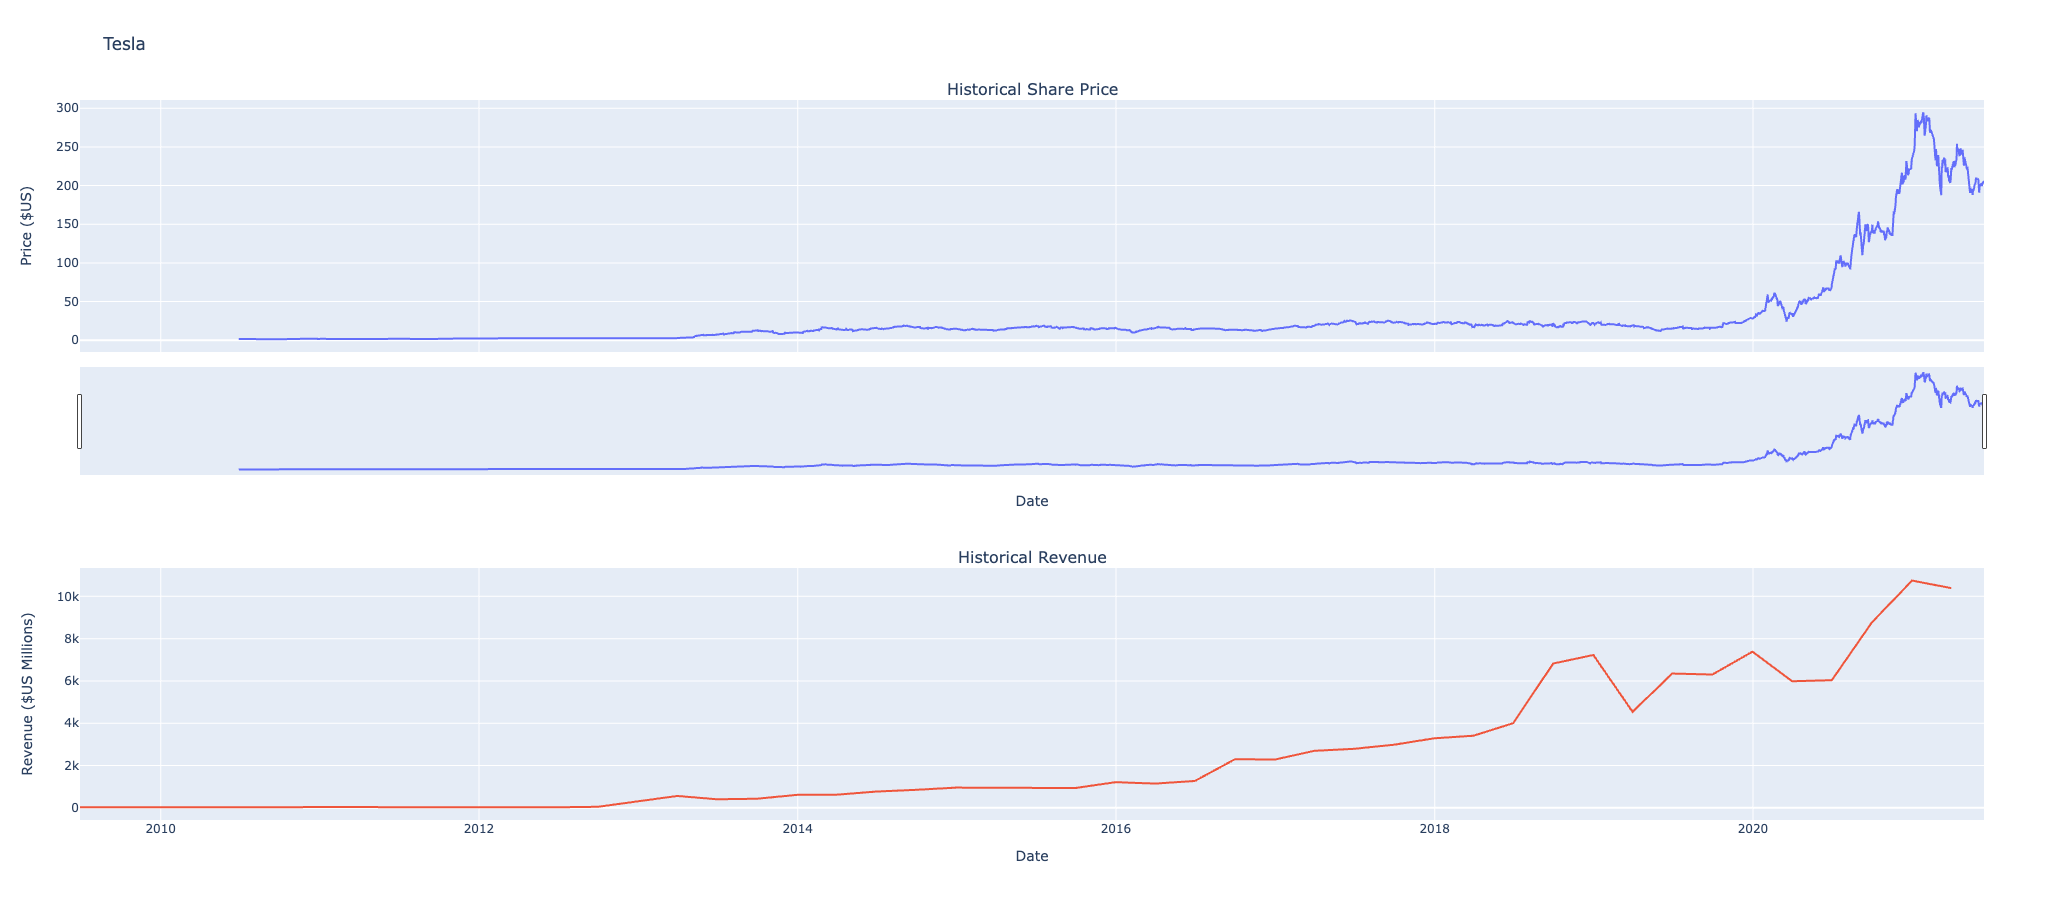

In [40]:
make_graph(tesla_data, tesla_revenue, "Tesla")

## Question 6: Plot GameStop Stock Graph


Use the `make_graph` function to graph the GameStop Stock Data, also provide a title for the graph. The structure to call the `make_graph` function is `make_graph(gme_data, gme_revenue, 'GameStop')`. Note the graph will only show data upto June 2021.


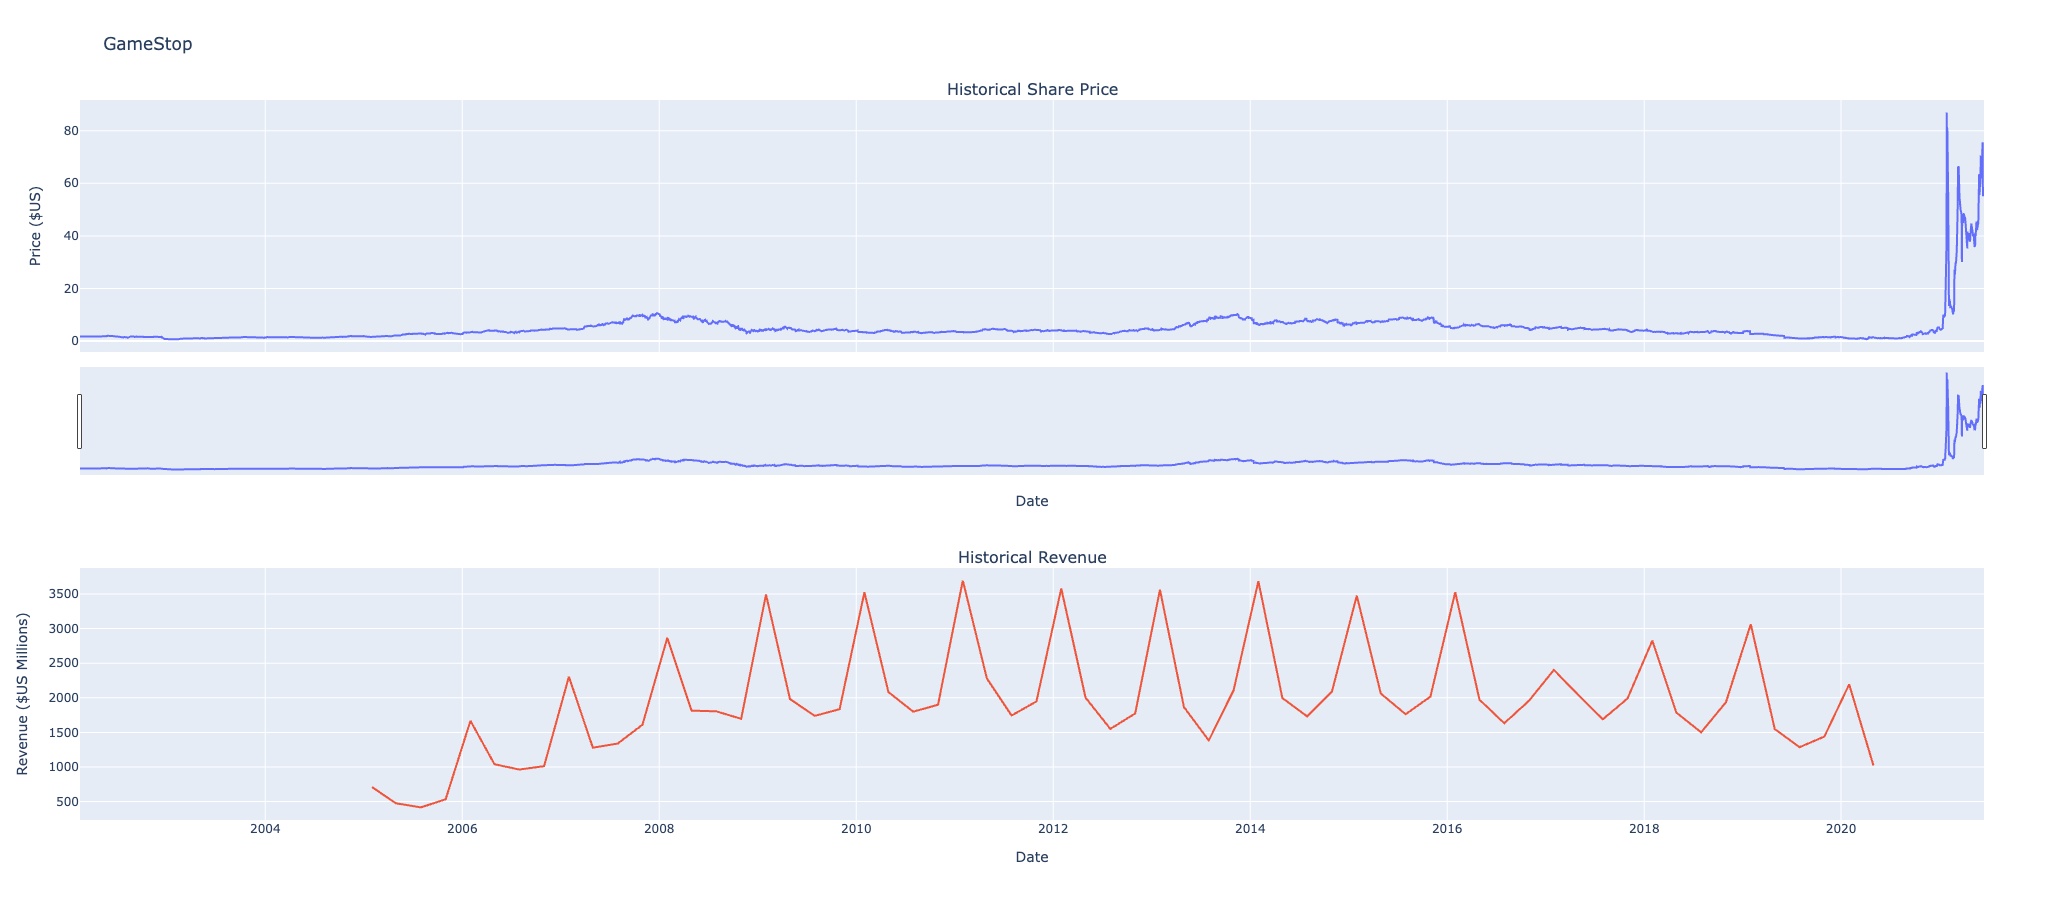

In [41]:
make_graph(gme_data,gme_revenue, "GameStop")

<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkPY0220ENSkillsNetwork900-2022-01-01">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.

Azim Hirjani


## Change Log

| Date (YYYY-MM-DD) | Version | Changed By    | Change Description        |
| ----------------- | ------- | ------------- | ------------------------- |
| 2022-02-28        | 1.2     | Lakshmi Holla | Changed the URL of GameStop |
| 2020-11-10        | 1.1     | Malika Singla | Deleted the Optional part |
| 2020-08-27        | 1.0     | Malika Singla | Added lab to GitLab       |

<hr>

## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>

<p>
